In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [2]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-20 16:12:08.375142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779293528.914853      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779293529.033793      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779293530.103618      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293530.103669      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293530.103672      23 computation_placer.cc:177] computation placer alr

In [4]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=d08fcda0a646ab5e805df4a122fc4ed225ce4c8d6a706b9f7aee262803a8ca93
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-20 16:13:14--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M   165MB/s    in 0.2s    

2026-05-20 16:13:14 (165 MB/s) - ‘VnCoreNLP

In [5]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [6]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"


# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


In [7]:
train_df

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1
11422,em cảm ơn cô nhiều .,2,0
11423,giao bài tập quá nhiều .,0,0
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['cleaned_text'].apply(word_segment)
val_df['sentence_seg'] = val_df['cleaned_text'].apply(word_segment)
test_df['sentence_seg'] = test_df['cleaned_text'].apply(word_segment)
test_df1['sentence_seg'] = test_df1['cleaned_text'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,cleaned_text,sentence_seg
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full điểm chuyên_cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


# B1a MTL Hard Sharing + CE
# B2a MTL Cross Attention + CE
# B3a MTL Soft Sharing + CE
# B4a MTL MMoE + CE
# B5a MTL Hard Sharing + PCGrad + CE
# B6a MTL Soft Sharing + PCGrad + CE

In [ ]:
# config
MODEL_NAME   = "xlm-roberta-base"
MAX_LEN      = 128
BATCH_SIZE   = 16
ACCUM_STEPS  = 2
LR           = 2e-5
LR_ENCODER   = 2e-5   
LR_HEADS     = 1e-4   # LR cho Classification Heads và Cross-Attention
DROPOUT      = 0.3    
EPOCHS       = 20
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
# PATIENCE     = 3
PATIENCE      = 5       
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]
 
print(f"Device : {DEVICE}")
print(f"Encoder: {MODEL_NAME}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }

def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        df["cleaned_text"].tolist(),
        # df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test cho MTL
def diagnose_validation(model, val_loader, model_name):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số"""
    model.eval()
    s_preds, s_labels, t_preds, t_labels = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            s_logit, t_logit = model(ids, mask)
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    print(f"\nChấn đoán trên validation === {model_name} ===")
    print("SENTIMENT:")
    print(classification_report(s_labels, s_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))
    print("TOPIC:")
    print(classification_report(t_labels, t_preds, target_names=["Lecturer", "Training", "Facility", "Others"], digits=4))

# Chẩn đoán trên tập val trước khi lưu test cho STL
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device : cuda
Encoder: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Hard Sharing 
class MTLHardSharing(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

# Cross-Task Attention
class CrossTaskAttention(nn.Module):
    def __init__(self, hidden_size, num_heads=4, dropout=0.3):
        super().__init__()
        self.attn_s2t = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_t2s = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_s   = nn.LayerNorm(hidden_size)
        self.norm_t   = nn.LayerNorm(hidden_size)

    def forward(self, sent_repr, topic_repr):
        s_refined, _ = self.attn_s2t(sent_repr.unsqueeze(1), topic_repr.unsqueeze(1), topic_repr.unsqueeze(1))
        t_refined, _ = self.attn_t2s(topic_repr.unsqueeze(1), sent_repr.unsqueeze(1), sent_repr.unsqueeze(1))
        s_out = self.norm_s(sent_repr + s_refined.squeeze(1))
        t_out = self.norm_t(topic_repr + t_refined.squeeze(1))
        return s_out, t_out

class MTLCrossTask(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3, head_dropout=0.3): # Thêm tham số head_dropout
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        self.sent_proj  = nn.Linear(hidden, hidden)
        self.topic_proj = nn.Linear(hidden, hidden)
        self.cross_attn = CrossTaskAttention(hidden, num_heads=4, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.head_dropout = nn.Dropout(head_dropout) # Dropout tăng cường trước classification

        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [B, H]

        s_repr = self.dropout(torch.relu(self.sent_proj(cls)))
        t_repr = self.dropout(torch.relu(self.topic_proj(cls)))

        s_refined, t_refined = self.cross_attn(s_repr, t_repr)
        
        # Áp dụng head_dropout trước khi chẻ nhánh
        return self.sent_head(self.head_dropout(s_refined)), self.topic_head(self.head_dropout(t_refined))

class MTLSoftSharing(nn.Module):
    is_mtl = True  
    
    def __init__(self, model_name=MODEL_NAME, num_sentiment=3, num_topic=4, dropout=0.3):
        super(MTLSoftSharing, self).__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Mạng tháp ẩn riêng biệt (Private Towers) không chứa dropout ngẫu nhiên trước khi trộn
        self.sent_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.topic_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        # Tham số kết hợp học tập Cross-stitch
        self.cross_stitch_sent = nn.Parameter(torch.tensor([0.9, 0.1])) 
        self.cross_stitch_topic = nn.Parameter(torch.tensor([0.1, 0.9]))
        
        # Tầng dropout hợp nhất sau khi trộn đặc trưng để chống Overfit chuẩn
        self.mix_dropout = nn.Dropout(dropout)
        
        # Các Classification Heads đầu ra
        self.sent_head = nn.Linear(hidden_size, num_sentiment)
        self.topic_head = nn.Linear(hidden_size, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        rep_sent = self.sent_tower(cls_output)
        rep_topic = self.topic_tower(cls_output)
        
        # 1. Ràng buộc chuẩn hóa toán học bằng Softmax thực thụ
        w_sent = torch.softmax(self.cross_stitch_sent, dim=0)
        w_topic = torch.softmax(self.cross_stitch_topic, dim=0)
        
        # 2. Thực hiện mượn chéo tri thức chuyên biệt
        shared_sent = w_sent[0] * rep_sent + w_sent[1] * rep_topic
        shared_topic = w_topic[0] * rep_sent + w_topic[1] * rep_topic
        
        # 3. Áp dụng Dropout điều hòa bộ lọc sau khi trộn
        shared_sent = self.mix_dropout(shared_sent)
        shared_topic = self.mix_dropout(shared_topic)
        
        logits_sent = self.sent_head(shared_sent)
        logits_topic = self.topic_head(shared_topic)
        
        return logits_sent, logits_topic


# KIẾN TRÚC MMOE (MULTI-GATE MIXTURE-OF-EXPERTS)
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3), # Đồng bộ dropout 0.3 để giảm overfit
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        return self.network(x)

class MMoE_PhoBERT(nn.Module):
    is_mtl = True 
    
    def __init__(self, model_name=MODEL_NAME, num_experts=4, expert_dim=256, num_sentiment=NUM_SENTIMENT, num_topic=NUM_TOPIC):
        super(MMoE_PhoBERT, self).__init__()
        
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Tập hợp các chuyên gia
        self.experts = nn.ModuleList([
            ExpertNetwork(hidden_size, expert_dim) for _ in range(num_experts)
        ])
        
        # Mạng cổng (Gates) điều hướng chuyên gia cho từng tác vụ
        self.gate_sentiment = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        self.gate_topic = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        
        # Dropout bổ sung trước khi phân loại
        self.head_dropout = nn.Dropout(0.3)
        
        # Lớp phân loại
        self.head_sentiment = nn.Linear(expert_dim, num_sentiment)
        self.head_topic = nn.Linear(expert_dim, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :] 
        
        expert_outputs = torch.stack([expert(cls_repr) for expert in self.experts], dim=1)
        
        w_sentiment = self.gate_sentiment(cls_repr).unsqueeze(-1)
        w_topic = self.gate_topic(cls_repr).unsqueeze(-1)
        
        repr_sentiment = torch.sum(w_sentiment * expert_outputs, dim=1)
        repr_topic = torch.sum(w_topic * expert_outputs, dim=1)
        
        logits_sentiment = self.head_sentiment(self.head_dropout(repr_sentiment))
        logits_topic = self.head_topic(self.head_dropout(repr_topic))
        
        return logits_sentiment, logits_topic
        
# Focal Loss
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

import torch.nn.functional as F

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
        
        # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


def train_mtl(model, train_loader, val_loader, loss_fn_sent, loss_fn_topic, 
              lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, model_name="mtl", patience=PATIENCE):
    
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            logits_s, logits_t = model(ids, mask)
            
            loss_s = loss_fn_sent(logits_s, targets_s)
            loss_t = loss_fn_topic(logits_t, targets_t)
            
            # Đồng bộ toán học: Chia tỷ lệ tích lũy chính xác
            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()

        train_loss = train_loss / len(train_loader)

        # PHA KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s = [], []
        val_preds_t, val_targets_t = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                logits_s, logits_t = model(ids, mask)
                
                loss_s = loss_fn_sent(logits_s, targets_s)
                loss_t = loss_fn_topic(logits_t, targets_t)
                
                # Đồng bộ lambda nghiêm ngặt giống hệt pha Train
                loss = (lambda_s * loss_s) + (lambda_t * loss_t)
                
                val_loss += loss.item()
                val_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Sent F1: {val_f1_s:.4f} | Val Topic F1: {val_f1_t:.4f} | Avg Val F1: {val_avg_f1:.4f}")

        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Avg Val F1: {best_avg_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best_01.pt")
    return model, pd.DataFrame(history), best_avg_f1
    
def plot_mtl_history(history_df, title="MTL Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục Loss (Vẽ cả Train Loss và Val Loss)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Trục F1 (vẽ 2 đường cho 2 task trên tập Validation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Macro F1', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['sent_macro_f1'], label='Val Sentiment F1', color='tab:blue', marker='o')
    ax2.plot(history_df['epoch'], history_df['topic_macro_f1'], label='Val Topic F1', color='tab:green', marker='^')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title, fontweight='bold')
    fig.tight_layout()
    
    # Gộp legend của cả 2 trục cho gọn
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    

def evaluate_and_plot_mtl(model, loader, title_prefix="B1"):
    model.eval()
    s_preds, s_labels = [], []
    t_preds, t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Khác biệt là ở đây: lấy ra 2 logits
            s_logit, t_logit = model(ids, mask)
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    # --- IN REPORT ---
    print(f"\n=== {title_prefix}: SENTIMENT REPORT ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    print(classification_report(s_labels, s_preds, target_names=sent_names, digits=4))

    print(f"\n=== {title_prefix}: TOPIC REPORT ===")
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    print(classification_report(t_labels, t_preds, target_names=topic_names, digits=4))

    # --- VẼ CONFUSION MATRIX (2 HÌNH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(s_labels, s_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment CM ({title_prefix})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(t_labels, t_preds)
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic CM ({title_prefix})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()
    
    # Trả về kết quả để lưu vào bảng tổng kết
    return {
        "sent_macro_f1":  f1_score(s_labels, s_preds, average="macro"),
        "topic_macro_f1": f1_score(t_labels, t_preds, average="macro"),
        "sent_report":    classification_report(s_labels, s_preds, target_names=sent_names, digits=4, output_dict=True),
        "topic_report":   classification_report(t_labels, t_preds, target_names=topic_names, digits=4, output_dict=True),
    }

In [ ]:
class PCGrad:
    """
    Project Conflicting Gradients — Yu et al. 2020.
    Bản tối ưu hóa bộ nhớ (Memory-Efficient) dành riêng cho các mô hình lớn (PhoBERT).
    """
    def __init__(self, optimizer):
        self.optimizer = optimizer

    def zero_grad(self):
        self.optimizer.zero_grad(set_to_none=True)

    def step(self):
        self.optimizer.step()

    def pc_backward(self, losses):
        params = [p for group in self.optimizer.param_groups for p in group['params'] if p.requires_grad]
        num_tasks = len(losses)
        
        # 1. Lưu lại gradient lũy kế (nếu có, hỗ trợ Gradient Accumulation)
        saved_grads = [p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p) for p in params]
        
        # 2. Thu thập gradient cho từng task
        grads = []
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad(set_to_none=True)
            
            # SỬA LỖI CHÍ MẠNG OOM: Chỉ giữ đồ thị nếu CHƯA phải là task cuối cùng
            is_last_task = (i == num_tasks - 1)
            loss.backward(retain_graph=not is_last_task)
            
            task_grads = []
            for p in params:
                if p.grad is not None:
                    task_grads.append(p.grad.detach().clone())
                else:
                    task_grads.append(torch.zeros_like(p))
            grads.append(task_grads)
            
        # 3. PCGrad Projection (Chiếu xung đột - Xử lý In-place để tiết kiệm RAM)
        proj_grads = []
        for i in range(num_tasks):
            proj_grads.append([g.clone() for g in grads[i]])
            
        for i in range(num_tasks):
            indices = list(range(num_tasks))
            np.random.shuffle(indices)
            for j in indices:
                if i == j: continue
                for k in range(len(params)):
                    # Ép thành mảng 1D (view) không tốn bộ nhớ để tính toán
                    g_i = proj_grads[i][k].view(-1)
                    g_j = grads[j][k].view(-1)
                    
                    dot_p = torch.dot(g_i, g_j)
                    if dot_p < 0:
                        # Dùng phép trừ in-place (-=) để không cấp phát bộ nhớ mới
                        proj_grads[i][k] -= (dot_p / (torch.norm(g_j)**2 + 1e-8)) * grads[j][k]

        # 4. Ghi đè gradient tổng hợp
        self.optimizer.zero_grad(set_to_none=True)
        for k, p in enumerate(params):
            # Tính tổng thay vì dùng torch.stack để tránh memory spike
            merged = sum(proj_grads[t][k] for t in range(num_tasks))
            p.grad = saved_grads[k] + merged
            
        # 5. Dọn dẹp rác trên VRAM triệt để
        del grads, proj_grads, saved_grads, merged
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# HÀM TRAIN TÍCH HỢP PCGRAD (HỖ TRỢ LAMBDA & ACCUM_STEPS)
def train_pcgrad(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                 lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, 
                 model_name="mtl_pcgrad", patience=PATIENCE):

    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    base_optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    # Bọc optimizer chuẩn bằng PCGrad
    optimizer = PCGrad(base_optimizer)
    
    # Tính tổng step
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(base_optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: TRAIN
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)

            s_logit, t_logit = model(ids, mask) 
            
            # Tính loss nguyên bản
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)

            # ÁP DỤNG LAMBDA VÀ ACCUM_STEPS TRƯỚC KHI ĐƯA VÀO PCGRAD
            l_s_scaled = (loss_s * lambda_s) / accum_steps
            l_t_scaled = (loss_t * lambda_t) / accum_steps

            # PCGrad Backward với List các loss độc lập
            optimizer.pc_backward([l_s_scaled, l_t_scaled])
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()

        train_loss = train_loss / len(train_loader)

        # PHA 2: VALIDATION
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                s_logit, t_logit = model(ids, mask)
                loss_s = loss_sent_fn(s_logit, targets_s)
                loss_t = loss_topic_fn(t_logit, targets_t)
                
                # SỬA LỖI THỤT LỀ Ở ĐÂY & ÁP DỤNG LAMBDA
                val_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
                
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Sent F1: {val_f1_s:.4f} | Topic F1: {val_f1_t:.4f} | Avg F1: {val_avg_f1:.4f}")  
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"  ↑ New best Avg F1: {best_avg_f1:.4f}")
        else:
            no_improve += 1
            print(f"  No improve {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest avg macro F1 (val): {best_avg_f1:.4f}")
    return model, pd.DataFrame(history), best_avg_f1


B1a: MTL Hard Sharing + Standard CE


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.4222 | Val Loss: 0.3962 | Val Sent F1: 0.6175 | Val Topic F1: 0.4209 | Avg Val F1: 0.5192
New best (Avg Val F1: 0.5192)
Epoch 02 | Train Loss: 0.1728 | Val Loss: 0.2666 | Val Sent F1: 0.8182 | Val Topic F1: 0.7815 | Avg Val F1: 0.7999
New best (Avg Val F1: 0.7999)
Epoch 03 | Train Loss: 0.1314 | Val Loss: 0.2676 | Val Sent F1: 0.8365 | Val Topic F1: 0.7581 | Avg Val F1: 0.7973
Không cải thiện 1/5
Epoch 04 | Train Loss: 0.1065 | Val Loss: 0.2810 | Val Sent F1: 0.8004 | Val Topic F1: 0.7735 | Avg Val F1: 0.7869
Không cải thiện 2/5
Epoch 05 | Train Loss: 0.0884 | Val Loss: 0.2801 | Val Sent F1: 0.8471 | Val Topic F1: 0.8003 | Avg Val F1: 0.8237
New best (Avg Val F1: 0.8237)
Epoch 06 | Train Loss: 0.0738 | Val Loss: 0.2992 | Val Sent F1: 0.8509 | Val Topic F1: 0.7917 | Avg Val F1: 0.8213
Không cải thiện 1/5
Epoch 07 | Train Loss: 0.0620 | Val Loss: 0.3426 | Val Sent F1: 0.8157 | Val Topic F1: 0.7883 | Avg Val F1: 0.8020
Không cải thiện 2/5
Epoch 08 | Train Loss: 0.

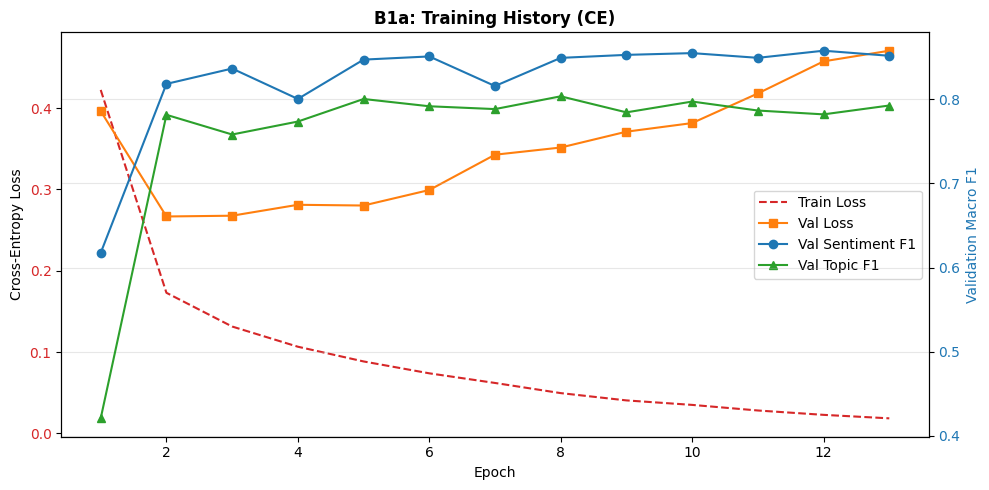


Chấn đoán trên validation === B1a_Hard_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9445    0.9660    0.9551       705
     Neutral     0.8605    0.5068    0.6379        73
    Positive     0.9463    0.9627    0.9544       805

    accuracy                         0.9431      1583
   macro avg     0.9171    0.8118    0.8492      1583
weighted avg     0.9415    0.9431    0.9401      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9410    0.9418    0.9414      1151
    Training     0.7509    0.8127    0.7806       267
    Facility     0.8933    0.9571    0.9241        70
      Others     0.6866    0.4842    0.5679        95

    accuracy                         0.8932      1583
   macro avg     0.8179    0.7990    0.8035      1583
weighted avg     0.8915    0.8932    0.8911      1583


=== B1a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9340

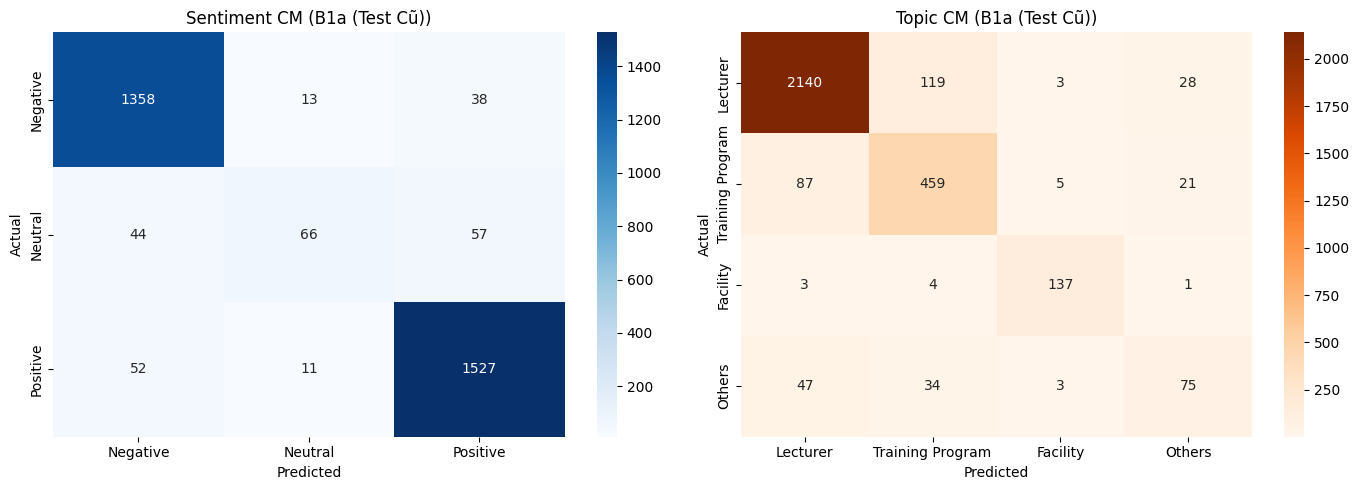


=== B1a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9422    0.9772    0.9594      1402
     Neutral     0.8000    0.4557    0.5806       158
    Positive     0.9636    0.9732    0.9684      1606

    accuracy                         0.9491      3166
   macro avg     0.9020    0.8020    0.8361      3166
weighted avg     0.9460    0.9491    0.9451      3166


=== B1a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9583    0.9516    0.9549      2293
Training Program     0.8198    0.8545    0.8368       591
        Facility     0.9527    0.9658    0.9592       146
          Others     0.6480    0.5956    0.6207       136

        accuracy                         0.9188      3166
       macro avg     0.8447    0.8419    0.8429      3166
    weighted avg     0.9188    0.9188    0.9187      3166



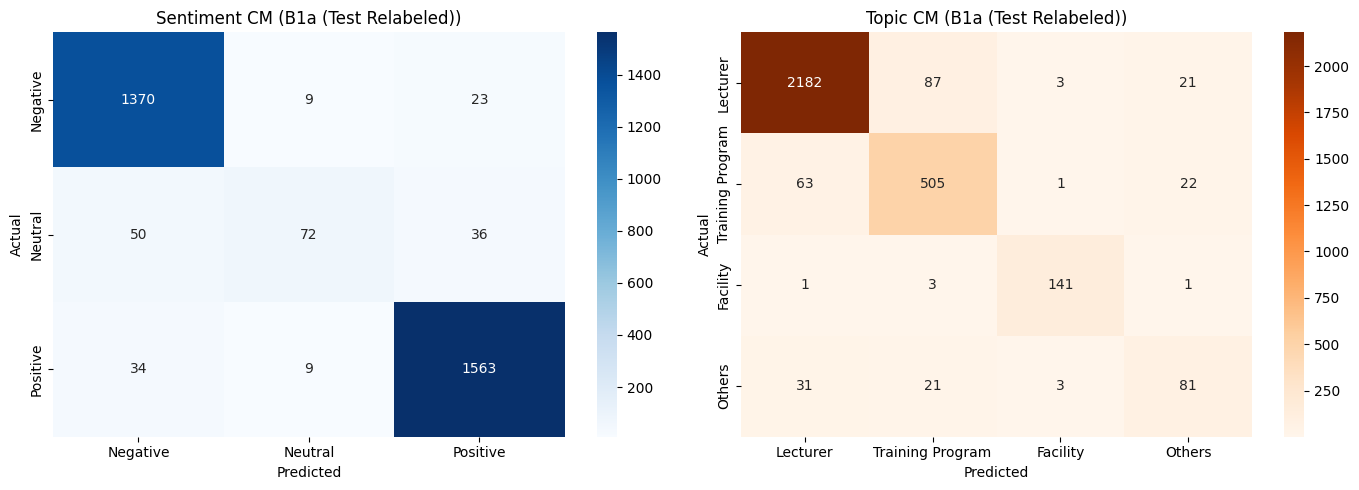


B2a: MTL Cross-Task Attention + Standard CE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.3599 | Val Loss: 0.3588 | Val Sent F1: 0.6376 | Val Topic F1: 0.6887 | Avg Val F1: 0.6632
New best (Avg Val F1: 0.6632)
Epoch 02 | Train Loss: 0.1656 | Val Loss: 0.3332 | Val Sent F1: 0.6990 | Val Topic F1: 0.7682 | Avg Val F1: 0.7336
New best (Avg Val F1: 0.7336)
Epoch 03 | Train Loss: 0.1338 | Val Loss: 0.3310 | Val Sent F1: 0.7318 | Val Topic F1: 0.7576 | Avg Val F1: 0.7447
New best (Avg Val F1: 0.7447)
Epoch 04 | Train Loss: 0.1127 | Val Loss: 0.3012 | Val Sent F1: 0.8239 | Val Topic F1: 0.7647 | Avg Val F1: 0.7943
New best (Avg Val F1: 0.7943)
Epoch 05 | Train Loss: 0.0972 | Val Loss: 0.3139 | Val Sent F1: 0.8261 | Val Topic F1: 0.7782 | Avg Val F1: 0.8022
New best (Avg Val F1: 0.8022)
Epoch 06 | Train Loss: 0.0827 | Val Loss: 0.2861 | Val Sent F1: 0.8528 | Val Topic F1: 0.7829 | Avg Val F1: 0.8179
New best (Avg Val F1: 0.8179)
Epoch 07 | Train Loss: 0.0681 | Val Loss: 0.3363 | Val Sent F1: 0.8359 | Val Topic F1: 0.7731 | Avg Val F1: 0.8045
Không cải thiện

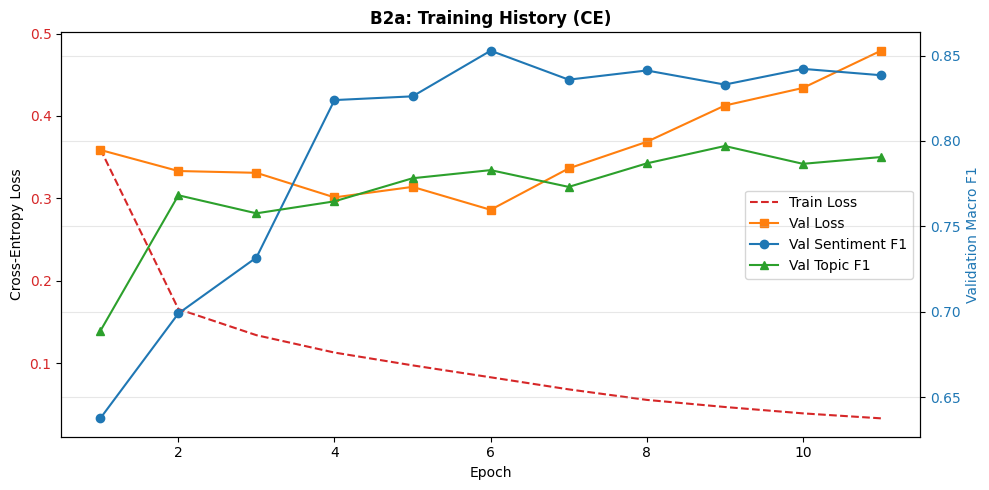


Chấn đoán trên validation === B2a_Cross_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9477    0.9759    0.9616       705
     Neutral     0.7800    0.5342    0.6341        73
    Positive     0.9616    0.9640    0.9628       805

    accuracy                         0.9495      1583
   macro avg     0.8964    0.8247    0.8528      1583
weighted avg     0.9470    0.9495    0.9471      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9142    0.9626    0.9378      1151
    Training     0.8058    0.7303    0.7662       267
    Facility     0.8889    0.9143    0.9014        70
      Others     0.7018    0.4211    0.5263        95

    accuracy                         0.8888      1583
   macro avg     0.8277    0.7571    0.7829      1583
weighted avg     0.8820    0.8888    0.8825      1583


=== B2a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.929

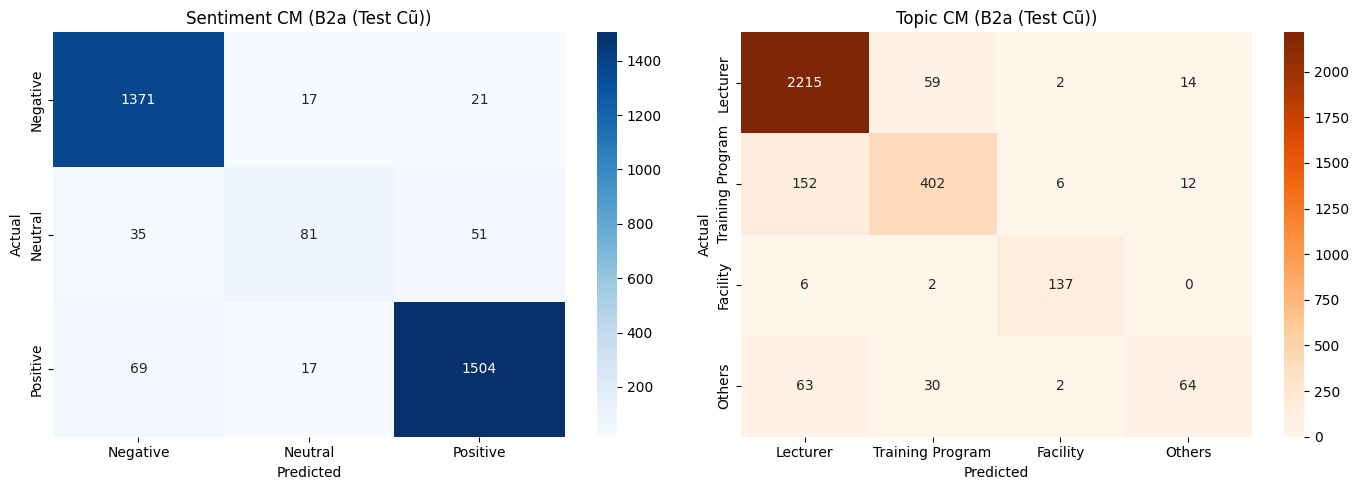


=== B2a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9369    0.9857    0.9607      1402
     Neutral     0.7739    0.5633    0.6520       158
    Positive     0.9791    0.9608    0.9698      1606

    accuracy                         0.9520      3166
   macro avg     0.8966    0.8366    0.8609      3166
weighted avg     0.9502    0.9520    0.9499      3166


=== B2a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9241    0.9817    0.9520      2293
Training Program     0.8986    0.7496    0.8173       591
        Facility     0.9592    0.9658    0.9625       146
          Others     0.8000    0.5294    0.6372       136

        accuracy                         0.9182      3166
       macro avg     0.8955    0.8066    0.8422      3166
    weighted avg     0.9156    0.9182    0.9138      3166



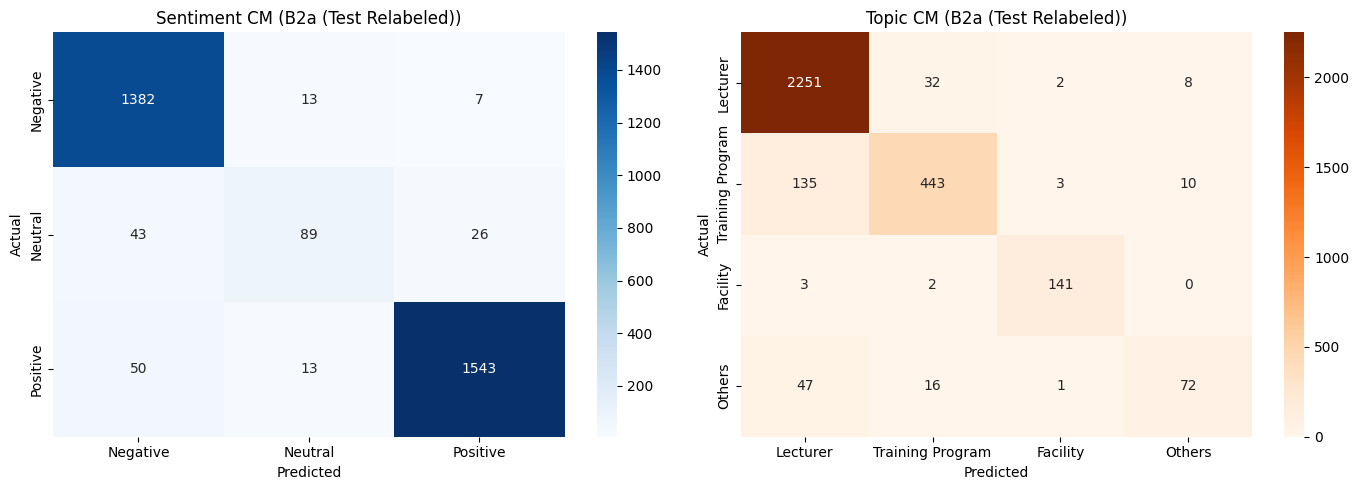


B3a: MTL Soft Sharing + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.4082 | Val Loss: 0.4410 | Val Sent F1: 0.6142 | Val Topic F1: 0.3428 | Avg Val F1: 0.4785
New best (Avg Val F1: 0.4785)
Epoch 02 | Train Loss: 0.1782 | Val Loss: 0.3231 | Val Sent F1: 0.6651 | Val Topic F1: 0.6826 | Avg Val F1: 0.6739
New best (Avg Val F1: 0.6739)
Epoch 03 | Train Loss: 0.1365 | Val Loss: 0.2625 | Val Sent F1: 0.7789 | Val Topic F1: 0.7783 | Avg Val F1: 0.7786
New best (Avg Val F1: 0.7786)
Epoch 04 | Train Loss: 0.1097 | Val Loss: 0.2764 | Val Sent F1: 0.8437 | Val Topic F1: 0.7905 | Avg Val F1: 0.8171
New best (Avg Val F1: 0.8171)
Epoch 05 | Train Loss: 0.0930 | Val Loss: 0.2978 | Val Sent F1: 0.8246 | Val Topic F1: 0.7570 | Avg Val F1: 0.7908
Không cải thiện 1/5
Epoch 06 | Train Loss: 0.0761 | Val Loss: 0.2631 | Val Sent F1: 0.8497 | Val Topic F1: 0.7999 | Avg Val F1: 0.8248
New best (Avg Val F1: 0.8248)
Epoch 07 | Train Loss: 0.0624 | Val Loss: 0.2974 | Val Sent F1: 0.8594 | Val Topic F1: 0.7869 | Avg Val F1: 0.8232
Không cải thiện 1/5
Epoch

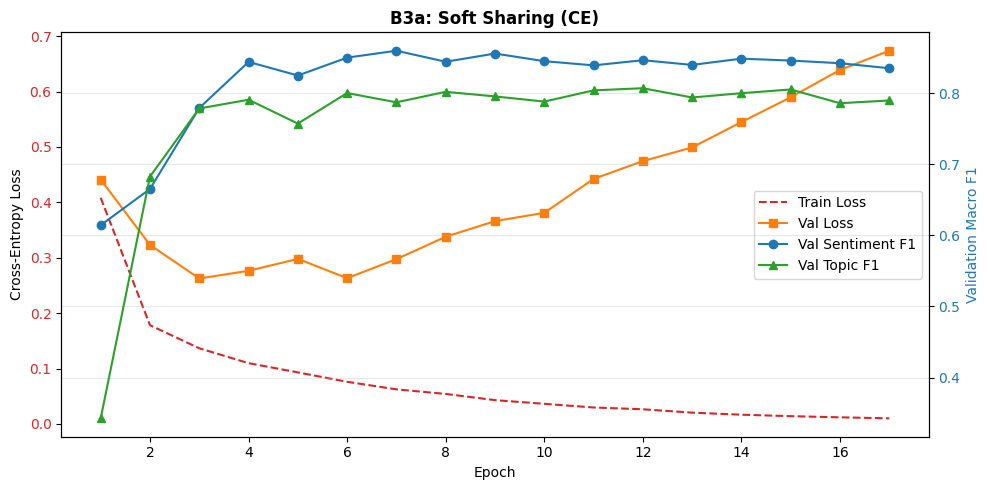


Chấn đoán trên validation === B3a_Soft_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9293    0.9688    0.9486       705
     Neutral     0.6825    0.5890    0.6324        73
    Positive     0.9694    0.9453    0.9572       805

    accuracy                         0.9394      1583
   macro avg     0.8604    0.8344    0.8461      1583
weighted avg     0.9383    0.9394    0.9384      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9345    0.9548    0.9446      1151
    Training     0.8008    0.7828    0.7917       267
    Facility     0.9275    0.9143    0.9209        70
      Others     0.6364    0.5158    0.5698        95

    accuracy                         0.8977      1583
   macro avg     0.8248    0.7919    0.8067      1583
weighted avg     0.8938    0.8977    0.8952      1583


=== B3a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9243

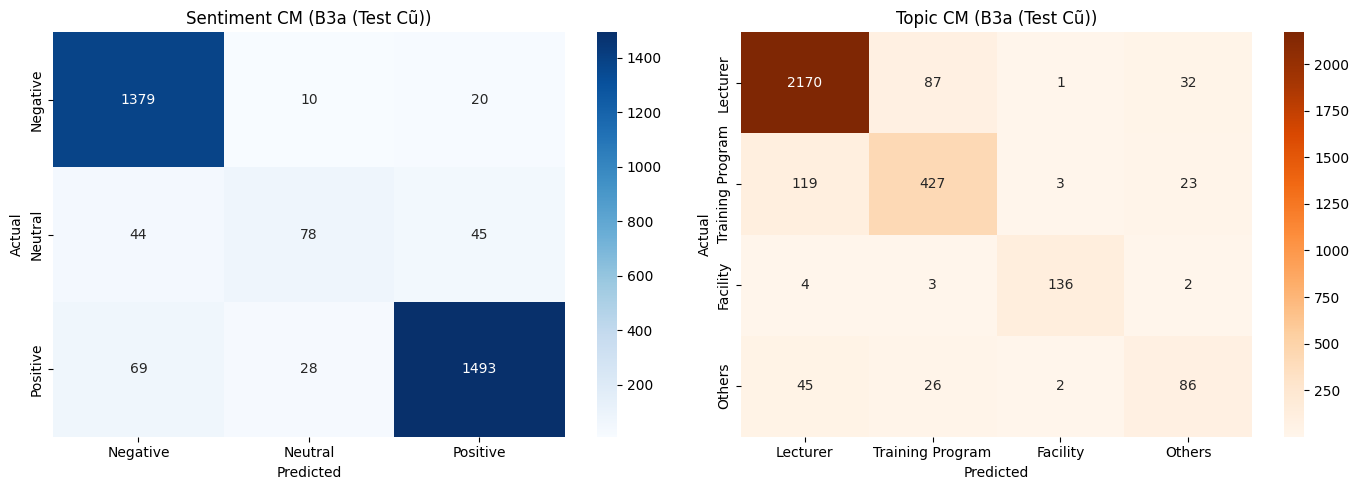


=== B3a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9310    0.9907    0.9599      1402
     Neutral     0.7328    0.5380    0.6204       158
    Positive     0.9820    0.9527    0.9671      1606

    accuracy                         0.9488      3166
   macro avg     0.8819    0.8271    0.8492      3166
weighted avg     0.9470    0.9488    0.9466      3166


=== B3a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9401    0.9586    0.9493      2293
Training Program     0.8471    0.7783    0.8113       591
        Facility     0.9859    0.9589    0.9722       146
          Others     0.6503    0.6838    0.6667       136

        accuracy                         0.9131      3166
       macro avg     0.8559    0.8449    0.8499      3166
    weighted avg     0.9124    0.9131    0.9124      3166



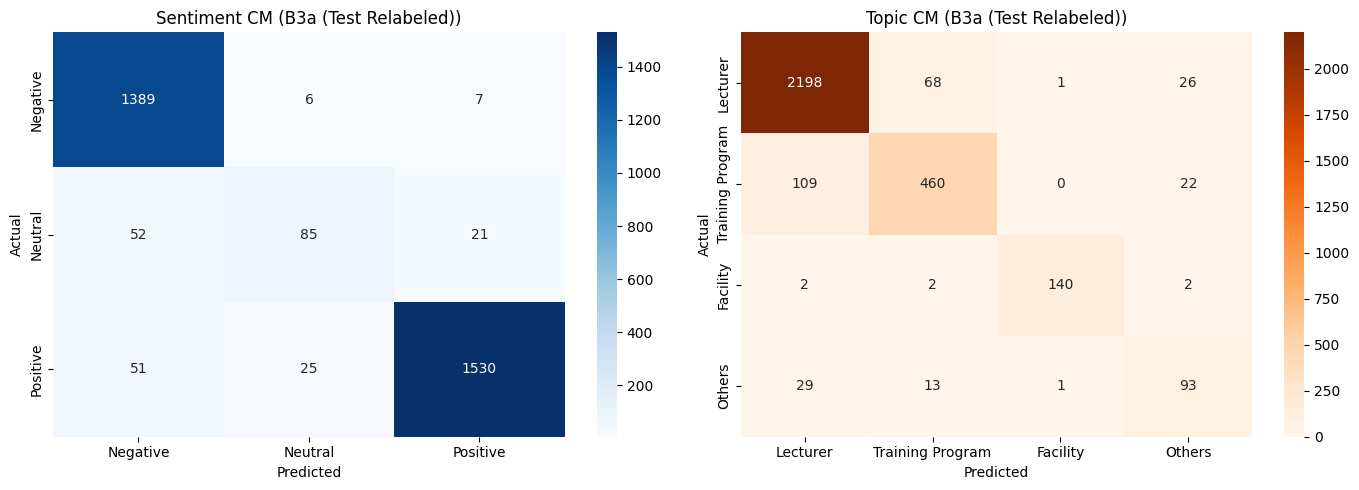


B4a: MMoE (Mixture-of-Experts) + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.4302 | Val Loss: 0.4547 | Val Sent F1: 0.6033 | Val Topic F1: 0.3276 | Avg Val F1: 0.4655
New best (Avg Val F1: 0.4655)
Epoch 02 | Train Loss: 0.1901 | Val Loss: 0.2996 | Val Sent F1: 0.7885 | Val Topic F1: 0.6446 | Avg Val F1: 0.7166
New best (Avg Val F1: 0.7166)
Epoch 03 | Train Loss: 0.1412 | Val Loss: 0.2805 | Val Sent F1: 0.8245 | Val Topic F1: 0.7070 | Avg Val F1: 0.7658
New best (Avg Val F1: 0.7658)
Epoch 04 | Train Loss: 0.1154 | Val Loss: 0.2647 | Val Sent F1: 0.8409 | Val Topic F1: 0.7756 | Avg Val F1: 0.8082
New best (Avg Val F1: 0.8082)
Epoch 05 | Train Loss: 0.0963 | Val Loss: 0.2755 | Val Sent F1: 0.8357 | Val Topic F1: 0.7979 | Avg Val F1: 0.8168
New best (Avg Val F1: 0.8168)
Epoch 06 | Train Loss: 0.0820 | Val Loss: 0.3190 | Val Sent F1: 0.8453 | Val Topic F1: 0.7728 | Avg Val F1: 0.8090
Không cải thiện 1/5
Epoch 07 | Train Loss: 0.0702 | Val Loss: 0.2997 | Val Sent F1: 0.8489 | Val Topic F1: 0.7803 | Avg Val F1: 0.8146
Không cải thiện 2/5
Epoch

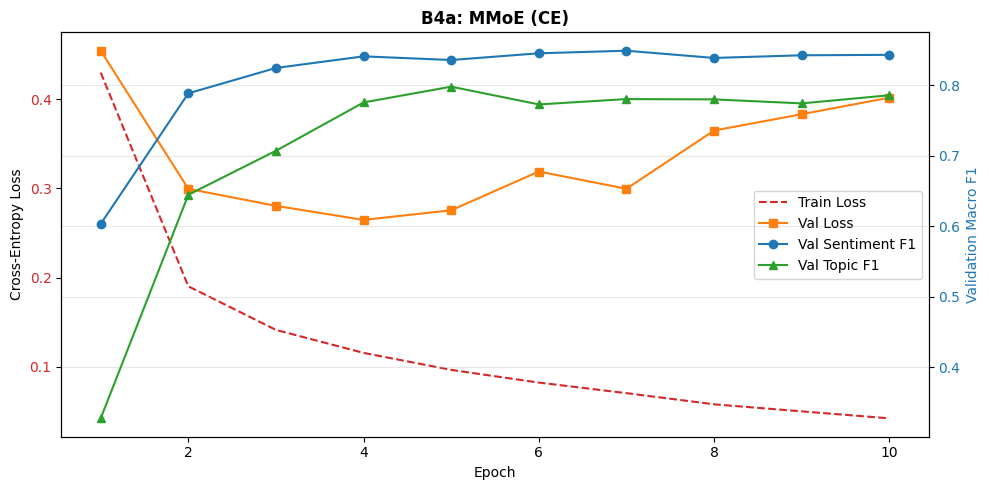


Chấn đoán trên validation === B4a_MMoE_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9566    0.9390    0.9477       705
     Neutral     0.6508    0.5616    0.6029        73
    Positive     0.9432    0.9702    0.9565       805

    accuracy                         0.9375      1583
   macro avg     0.8502    0.8236    0.8357      1583
weighted avg     0.9357    0.9375    0.9363      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9449    0.9383    0.9416      1151
    Training     0.7836    0.7865    0.7850       267
    Facility     0.9254    0.8857    0.9051        70
      Others     0.5333    0.5895    0.5600        95

    accuracy                         0.8895      1583
   macro avg     0.7968    0.8000    0.7979      1583
weighted avg     0.8921    0.8895    0.8907      1583


=== B4a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9486

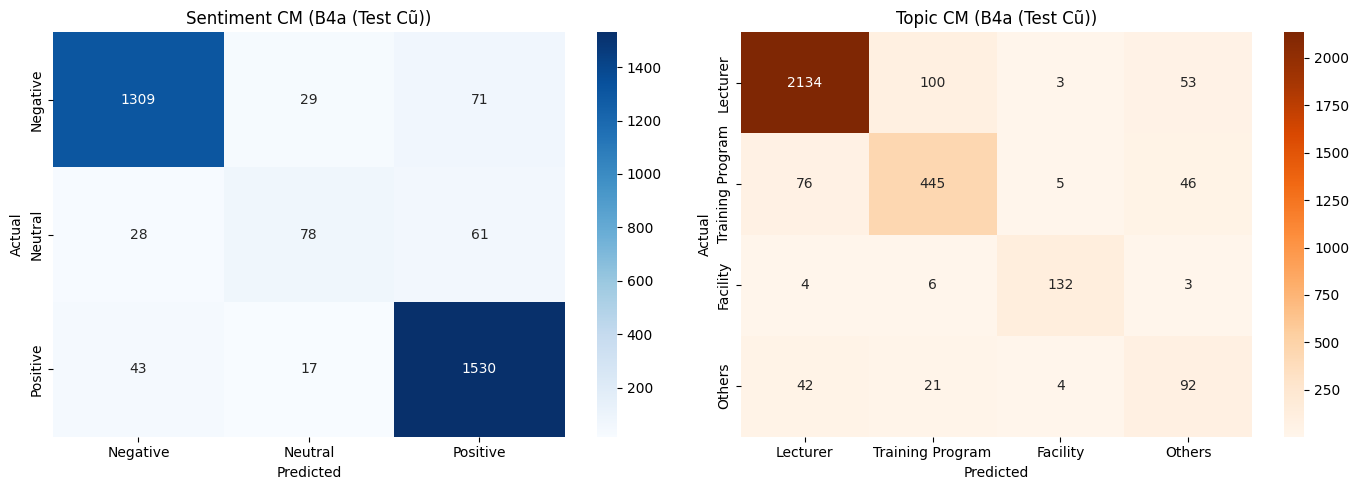


=== B4a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9572    0.9422    0.9497      1402
     Neutral     0.6694    0.5253    0.5887       158
    Positive     0.9440    0.9770    0.9602      1606

    accuracy                         0.9390      3166
   macro avg     0.8569    0.8148    0.8328      3166
weighted avg     0.9362    0.9390    0.9370      3166


=== B4a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9645    0.9490    0.9567      2293
Training Program     0.8462    0.8190    0.8323       591
        Facility     0.9375    0.9247    0.9310       146
          Others     0.5103    0.7279    0.6000       136

        accuracy                         0.9141      3166
       macro avg     0.8146    0.8551    0.8300      3166
    weighted avg     0.9217    0.9141    0.9170      3166



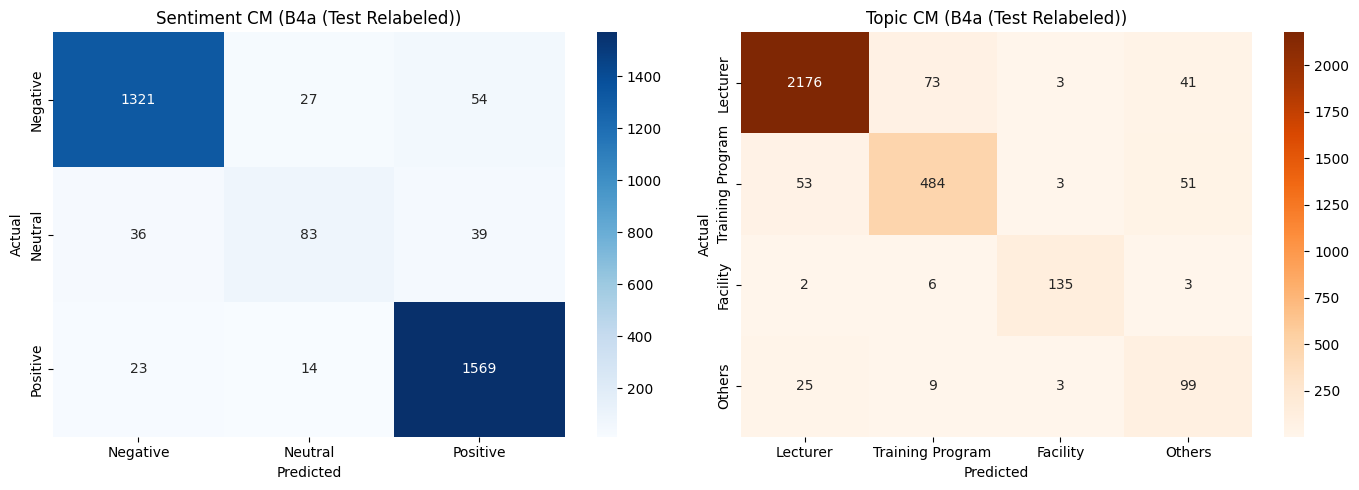


B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OutOfMemoryError: CUDA out of memory. Tried to allocate 734.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 135.81 MiB is free. Including non-PyTorch memory, this process has 14.43 GiB memory in use. Of the allocated memory 13.37 GiB is allocated by PyTorch, and 945.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# CHẠY THỰC NGHIỆM & ĐÁNH GIÁ TRÊN 2 TẬP TEST
results_old_test = {}
results_new_test = {}

# 1. Standard Cross Entropy (CE)
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

# 2. Weighted Cross Entropy (WCE) - Tích hợp Class Weights
wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

# 3. Focal Loss
focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

# 4. Asymmetric Loss (ASL)
asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)


# ── B1a: MTL Hard Sharing + Standard CE ──
print("\n" + "="*50)
print("B1a: MTL Hard Sharing + Standard CE")
print("="*50)
model_b1a = MTLHardSharing(dropout=0.3).to(DEVICE)
model_b1a, hist_b1a, val_f1_b1a = train_mtl(model_b1a, train_loader, val_loader, 
                                            ce_sent, ce_topic, model_name="B1a_Hard_CE")
plot_mtl_history(hist_b1a, title="B1a: Training History (CE)")
diagnose_validation(model_b1a, val_loader, "B1a_Hard_CE")
results_old_test["B1a_Hard_CE"] = evaluate_and_plot_mtl(model_b1a, test_loader, title_prefix="B1a (Test Cũ)")
results_new_test["B1a_Hard_CE"] = evaluate_and_plot_mtl(model_b1a, test_loader1, title_prefix="B1a (Test Relabeled)")


# ── B2a: MTL Cross-Task Attention + Standard CE ──
print("\n" + "="*50)
print("B2a: MTL Cross-Task Attention + Standard CE")
print("="*50)
model_b2a = MTLCrossTask(dropout=0.3, head_dropout=0.3).to(DEVICE)
model_b2a, hist_b2a, val_f1_b2a = train_mtl(model_b2a, train_loader, val_loader, 
                                            ce_sent, ce_topic, model_name="B2a_Cross_CE")
plot_mtl_history(hist_b2a, title="B2a: Training History (CE)")
diagnose_validation(model_b2a, val_loader, "B2a_Cross_CE")
results_old_test["B2a_Cross_CE"] = evaluate_and_plot_mtl(model_b2a, test_loader, title_prefix="B2a (Test Cũ)")
results_new_test["B2a_Cross_CE"] = evaluate_and_plot_mtl(model_b2a, test_loader1, title_prefix="B2a (Test Relabeled)")

# ── B3a: MTL Soft Sharing + Standard CE ──
print("\n" + "="*60)
print("B3a: MTL Soft Sharing + Standard CE (Lambda 0.6/0.4)")
print("="*60)
model_b3a = MTLSoftSharing(dropout=0.3).to(DEVICE)
model_b3a, hist_b3a, val_f1_b3a = train_mtl(model_b3a, train_loader, val_loader, 
                                            ce_sent, ce_topic, 
                                            lambda_s=0.6, lambda_t=0.4, 
                                            model_name="B3a_Soft_CE")
plot_mtl_history(hist_b3a, title="B3a: Soft Sharing (CE)")
diagnose_validation(model_b3a, val_loader, "B3a_Soft_CE")
results_old_test["B3a_Soft_CE"] = evaluate_and_plot_mtl(model_b3a, test_loader, title_prefix="B3a (Test Cũ)")
results_new_test["B3a_Soft_CE"] = evaluate_and_plot_mtl(model_b3a, test_loader1, title_prefix="B3a (Test Relabeled)")


# ── B4a: MMoE + Standard CE ──
print("\n" + "="*60)
print("B4a: MMoE (Mixture-of-Experts) + Standard CE (Lambda 0.6/0.4)")
print("="*60)
model_b4a = MMoE_PhoBERT().to(DEVICE)
model_b4a, hist_b4a, val_f1_b4a = train_mtl(model_b4a, train_loader, val_loader, 
                                            ce_sent, ce_topic, 
                                            lambda_s=0.6, lambda_t=0.4, 
                                            model_name="B4a_MMoE_CE")
plot_mtl_history(hist_b4a, title="B4a: MMoE (CE)")
diagnose_validation(model_b4a, val_loader, "B4a_MMoE_CE")
results_old_test["B4a_MMoE_CE"] = evaluate_and_plot_mtl(model_b4a, test_loader, title_prefix="B4a (Test Cũ)")
results_new_test["B4a_MMoE_CE"] = evaluate_and_plot_mtl(model_b4a, test_loader1, title_prefix="B4a (Test Relabeled)")

# ── B5a: MTL Hard Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

# 1. Khởi tạo đúng mô hình và biến
model_b5a = MTLHardSharing(dropout=0.3).to(DEVICE)

# 2. Gọi hàm train_pcgrad thay vì train_mtl
model_b5a, hist_b5a, val_f1_b5a = train_pcgrad(
    model=model_b5a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent,      # Chú ý tên tham số của hàm PCGrad
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5a_Hard_PCGrad_CE"
)

# 3. Đánh giá và lưu kết quả với đúng tên biến B5a
plot_mtl_history(hist_b5a, title="B5a: Hard Sharing + PCGrad (CE)")
diagnose_validation(model_b5a, val_loader, "B5a_Hard_PCGrad_CE") 
results_old_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader, title_prefix="B5a (Test Cũ)")
results_new_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader1, title_prefix="B5a (Test Relabeled)")


# ── B6a: MTL Soft Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B6a: MTL Soft Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

# 1. Khởi tạo đúng mô hình và biến
model_b6a = MTLSoftSharing(dropout=0.3).to(DEVICE)

# 2. Gọi hàm train_pcgrad
model_b6a, hist_b6a, val_f1_b6a = train_pcgrad(
    model=model_b6a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent, 
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B6a_Soft_PCGrad_CE"
)

# 3. Đánh giá và lưu kết quả với đúng tên biến B6a
plot_mtl_history(hist_b6a, title="B6a: Soft Sharing + PCGrad (CE)")
diagnose_validation(model_b6a, val_loader, "B6a_Soft_PCGrad_CE") 
results_old_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader, title_prefix="B6a (Test Cũ)")
results_new_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader1, title_prefix="B6a (Test Relabeled)")

# 6. IN BẢNG SO SÁNH KẾT QUẢ CHO CẢ 2 TEST SET
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

def generate_result_dataframe(results_dict):
    rows = []
    for name, res in results_dict.items():
        s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
        t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
        rows.append({
            "Model":            name,
            "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
            "Sent macro-F1":    round(res["sent_macro_f1"], 4),
            "S-Negative":       s_per["Negative"],
            "S-Neutral*":       s_per["Neutral"],      
            "S-Positive":       s_per["Positive"],
            "Topic macro-F1":   round(res["topic_macro_f1"], 4),
            "T-Lecturer":       t_per["Lecturer"],
            "T-Training":       t_per["Training Program"],
            "T-Facility*":      t_per["Facility"],     
            "T-Others*":        t_per["Others"],       
        })
    return pd.DataFrame(rows).set_index("Model")

df_results_old = generate_result_dataframe(results_old_test)
df_results_new = generate_result_dataframe(results_new_test)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)")
print("=" * 110)
print(df_results_old.to_string())

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)")
print("=" * 110)
print(df_results_new.to_string())
print("\n(*) Ghi chú: Các lớp có dấu * là lớp thiểu số mất cân bằng dữ liệu.")


B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.4142 | Val Loss: 0.3798 | Sent F1: 0.6175 | Topic F1: 0.4992 | Avg F1: 0.5584
  ↑ New best Avg F1: 0.5584
Epoch 02 | Train Loss: 0.1686 | Val Loss: 0.2650 | Sent F1: 0.7806 | Topic F1: 0.7897 | Avg F1: 0.7852
  ↑ New best Avg F1: 0.7852
Epoch 03 | Train Loss: 0.1293 | Val Loss: 0.2715 | Sent F1: 0.7984 | Topic F1: 0.7616 | Avg F1: 0.7800
  No improve 1/5
Epoch 04 | Train Loss: 0.1098 | Val Loss: 0.2691 | Sent F1: 0.8206 | Topic F1: 0.7814 | Avg F1: 0.8010
  ↑ New best Avg F1: 0.8010
Epoch 05 | Train Loss: 0.0885 | Val Loss: 0.2693 | Sent F1: 0.8567 | Topic F1: 0.7936 | Avg F1: 0.8252
  ↑ New best Avg F1: 0.8252
Epoch 06 | Train Loss: 0.0747 | Val Loss: 0.3148 | Sent F1: 0.8372 | Topic F1: 0.7928 | Avg F1: 0.8150
  No improve 1/5
Epoch 07 | Train Loss: 0.0634 | Val Loss: 0.3369 | Sent F1: 0.8284 | Topic F1: 0.7967 | Avg F1: 0.8125
  No improve 2/5
Epoch 08 | Train Loss: 0.0495 | Val Loss: 0.3324 | Sent F1: 0.8451 | Topic F1: 0.8014 | Avg F1: 0.8233
  No improve 

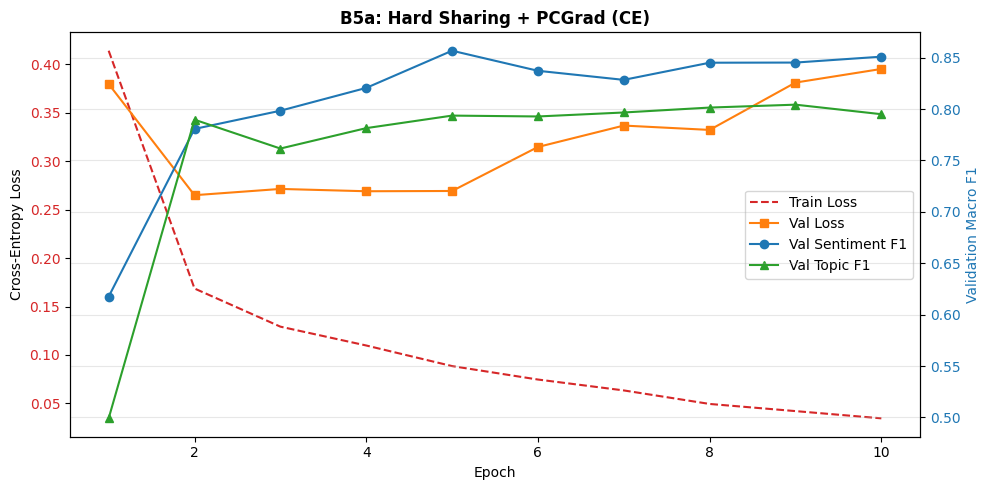


Chấn đoán trên validation === B5a_Hard_PCGrad_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9469    0.9603    0.9535       705
     Neutral     0.7636    0.5753    0.6562        73
    Positive     0.9557    0.9652    0.9604       805

    accuracy                         0.9450      1583
   macro avg     0.8887    0.8336    0.8567      1583
weighted avg     0.9429    0.9450    0.9433      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9537    0.9305    0.9420      1151
    Training     0.7095    0.8689    0.7811       267
    Facility     0.8750    0.9000    0.8873        70
      Others     0.7213    0.4632    0.5641        95

    accuracy                         0.8907      1583
   macro avg     0.8149    0.7906    0.7936      1583
weighted avg     0.8951    0.8907    0.8897      1583


=== B5a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative    

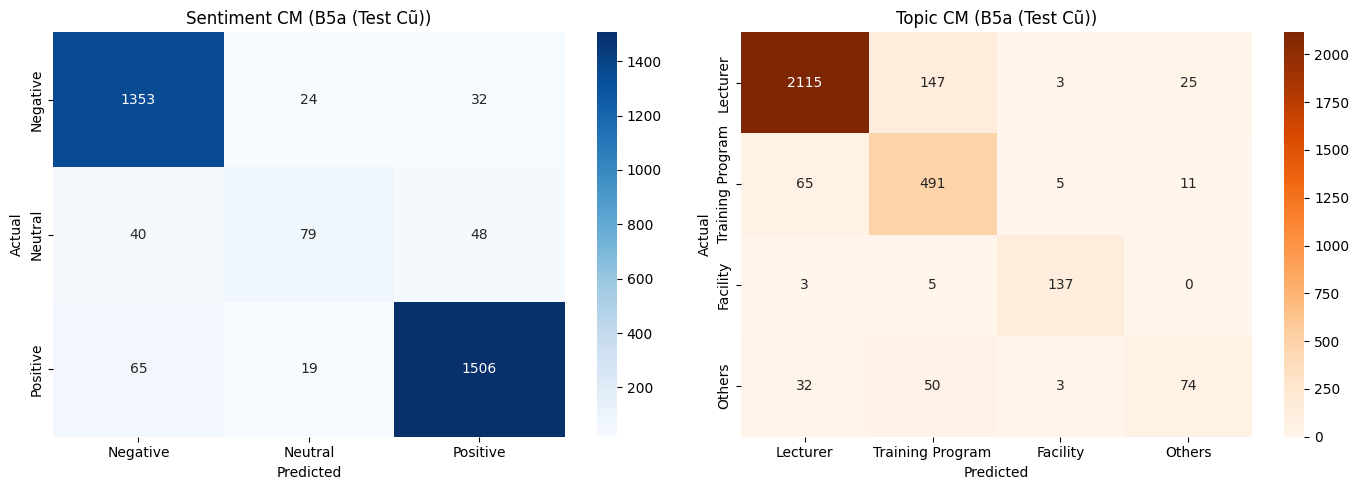


=== B5a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9348    0.9722    0.9531      1402
     Neutral     0.6885    0.5316    0.6000       158
    Positive     0.9729    0.9608    0.9668      1606

    accuracy                         0.9444      3166
   macro avg     0.8654    0.8215    0.8400      3166
weighted avg     0.9418    0.9444    0.9424      3166


=== B5a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9720    0.9389    0.9552      2293
Training Program     0.7734    0.9069    0.8349       591
        Facility     0.9459    0.9589    0.9524       146
          Others     0.7364    0.5956    0.6585       136

        accuracy                         0.9191      3166
       macro avg     0.8569    0.8501    0.8502      3166
    weighted avg     0.9236    0.9191    0.9199      3166



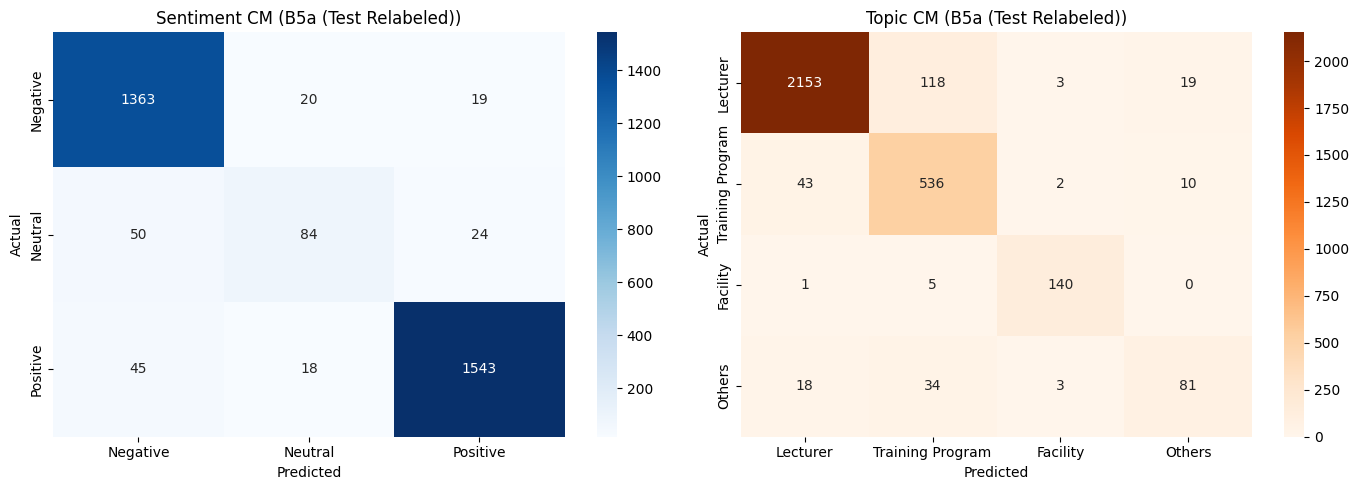


B6a: MTL Soft Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.3876 | Val Loss: 0.4407 | Sent F1: 0.6137 | Topic F1: 0.3796 | Avg F1: 0.4967
  ↑ New best Avg F1: 0.4967
Epoch 02 | Train Loss: 0.1731 | Val Loss: 0.3091 | Sent F1: 0.7720 | Topic F1: 0.7540 | Avg F1: 0.7630
  ↑ New best Avg F1: 0.7630
Epoch 03 | Train Loss: 0.1315 | Val Loss: 0.2473 | Sent F1: 0.8015 | Topic F1: 0.7613 | Avg F1: 0.7814
  ↑ New best Avg F1: 0.7814
Epoch 04 | Train Loss: 0.1078 | Val Loss: 0.2637 | Sent F1: 0.8317 | Topic F1: 0.7997 | Avg F1: 0.8157
  ↑ New best Avg F1: 0.8157
Epoch 05 | Train Loss: 0.0914 | Val Loss: 0.2922 | Sent F1: 0.8255 | Topic F1: 0.7987 | Avg F1: 0.8121
  No improve 1/5
Epoch 06 | Train Loss: 0.0753 | Val Loss: 0.3034 | Sent F1: 0.8342 | Topic F1: 0.7919 | Avg F1: 0.8131
  No improve 2/5
Epoch 07 | Train Loss: 0.0658 | Val Loss: 0.3342 | Sent F1: 0.8375 | Topic F1: 0.7953 | Avg F1: 0.8164
  ↑ New best Avg F1: 0.8164
Epoch 08 | Train Loss: 0.0532 | Val Loss: 0.3301 | Sent F1: 0.8395 | Topic F1: 0.7944 | Avg F1: 0.8169
  

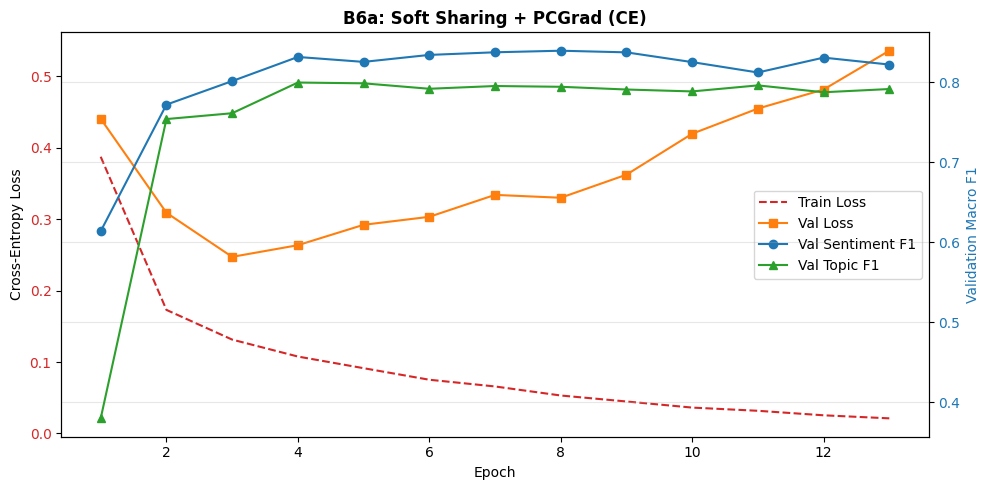


Chấn đoán trên validation === B6a_Soft_PCGrad_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9444    0.9631    0.9537       705
     Neutral     0.7170    0.5205    0.6032        73
    Positive     0.9581    0.9652    0.9616       805

    accuracy                         0.9438      1583
   macro avg     0.8731    0.8163    0.8395      1583
weighted avg     0.9409    0.9438    0.9415      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9390    0.9496    0.9443      1151
    Training     0.7887    0.7828    0.7857       267
    Facility     0.8684    0.9429    0.9041        70
      Others     0.6026    0.4947    0.5434        95

    accuracy                         0.8939      1583
   macro avg     0.7997    0.7925    0.7944      1583
weighted avg     0.8903    0.8939    0.8917      1583


=== B6a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative    

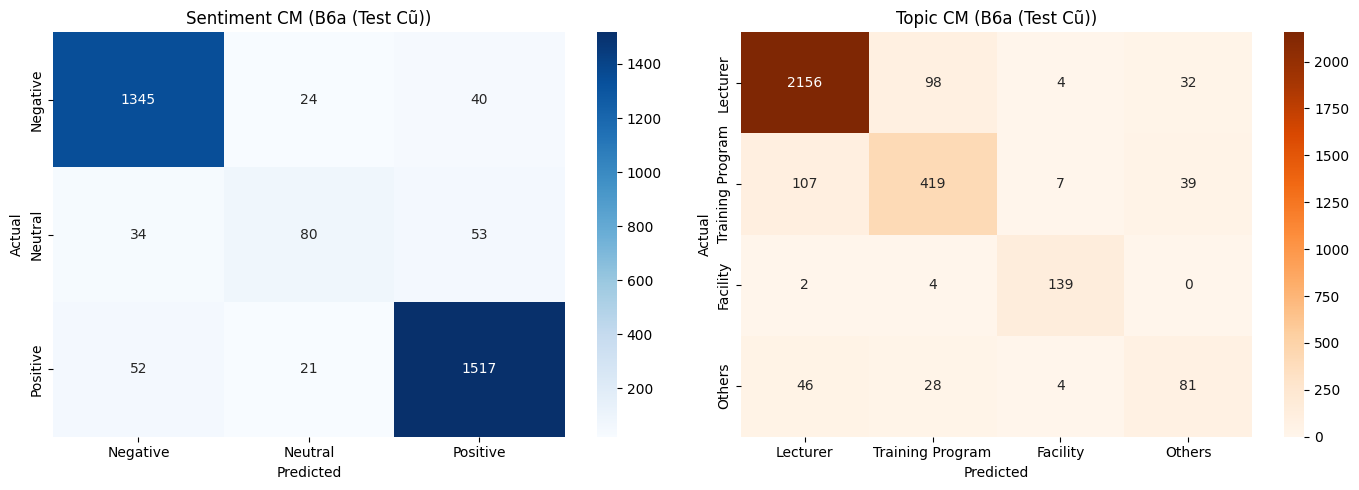


=== B6a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9490    0.9686    0.9587      1402
     Neutral     0.7040    0.5570    0.6219       158
    Positive     0.9677    0.9701    0.9689      1606

    accuracy                         0.9488      3166
   macro avg     0.8736    0.8319    0.8498      3166
weighted avg     0.9463    0.9488    0.9471      3166


=== B6a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9485    0.9560    0.9522      2293
Training Program     0.8379    0.7783    0.8070       591
        Facility     0.9286    0.9795    0.9533       146
          Others     0.5921    0.6618    0.6250       136

        accuracy                         0.9112      3166
       macro avg     0.8268    0.8439    0.8344      3166
    weighted avg     0.9116    0.9112    0.9111      3166



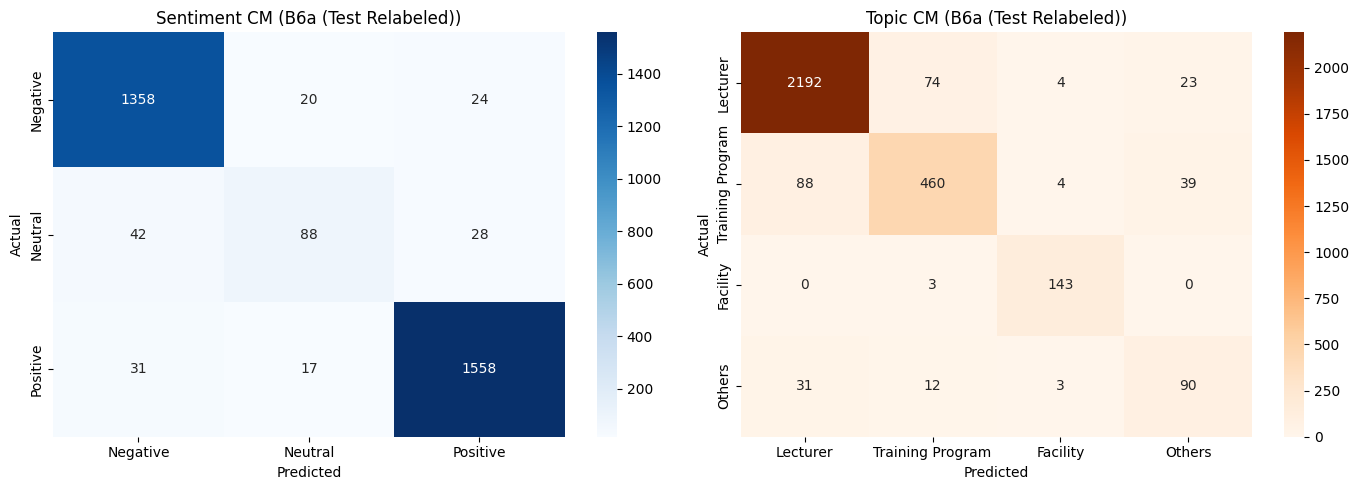


ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)
                    Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                              
B5a_Hard_PCGrad_CE        0.8066         0.8130      0.9438      0.5467      0.9484          0.8001      0.9390      0.7763       0.9352     0.5502
B6a_Soft_PCGrad_CE        0.7991         0.8144      0.9472      0.5479      0.9481          0.7839      0.9372      0.7475       0.9298     0.5209

ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)
                    Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                            

In [ ]:
# ── B5a: MTL Hard Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

model_b5a = MTLHardSharing(dropout=0.3).to(DEVICE)

model_b5a, hist_b5a, val_f1_b5a = train_pcgrad(
    model=model_b5a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent,      
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5a_Hard_PCGrad_CE"
)

plot_mtl_history(hist_b5a, title="B5a: Hard Sharing + PCGrad (CE)")
diagnose_validation(model_b5a, val_loader, "B5a_Hard_PCGrad_CE") 
results_old_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader, title_prefix="B5a (Test Cũ)")
results_new_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader1, title_prefix="B5a (Test Relabeled)")


# ── B6a: MTL Soft Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B6a: MTL Soft Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

model_b6a = MTLSoftSharing(dropout=0.3).to(DEVICE)

model_b6a, hist_b6a, val_f1_b6a = train_pcgrad(
    model=model_b6a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent, 
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B6a_Soft_PCGrad_CE"
)

plot_mtl_history(hist_b6a, title="B6a: Soft Sharing + PCGrad (CE)")
diagnose_validation(model_b6a, val_loader, "B6a_Soft_PCGrad_CE") 
results_old_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader, title_prefix="B6a (Test Cũ)")
results_new_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader1, title_prefix="B6a (Test Relabeled)")

# IN BẢNG SO SÁNH KẾT QUẢ CHO CẢ 2 TEST SET
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

def generate_result_dataframe(results_dict):
    rows = []
    for name, res in results_dict.items():
        s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
        t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
        rows.append({
            "Model":            name,
            "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
            "Sent macro-F1":    round(res["sent_macro_f1"], 4),
            "S-Negative":       s_per["Negative"],
            "S-Neutral*":       s_per["Neutral"],      
            "S-Positive":       s_per["Positive"],
            "Topic macro-F1":   round(res["topic_macro_f1"], 4),
            "T-Lecturer":       t_per["Lecturer"],
            "T-Training":       t_per["Training Program"],
            "T-Facility*":      t_per["Facility"],     
            "T-Others*":        t_per["Others"],       
        })
    return pd.DataFrame(rows).set_index("Model")

df_results_old = generate_result_dataframe(results_old_test)
df_results_new = generate_result_dataframe(results_new_test)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)")
print("=" * 110)
print(df_results_old.to_string())

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)")
print("=" * 110)
print(df_results_new.to_string())
print("\n(*) Ghi chú: Các lớp có dấu * là lớp thiểu số mất cân bằng dữ liệu.")